# Finite cylindrical wire model in the lab frame

This notebook models the magnetic field of a **finite cylindrical wire** above the `xy` plane.

## Geometry
- Scan area: `200 µm × 200 µm`
- Grid step: `5 µm`
- Observation plane: `z = 0`
- Wire axis: parallel to the `y-axis`
- Wire length: `200 µm`
- Wire radius: `25 µm`
- Wire bottom: `10 µm` above the plane
- Wire center height: `35 µm`

## Current waveform
The current is biphasic:
- `0 mA` before the drive
- `+2 mA` during the positive phase
- `-2 mA` during the negative phase
- `0 mA` again afterward

## Physics and mathematical model

Instead of representing the wire as one or more ideal line currents, this notebook models it as a **solid cylindrical conductor** with a **uniform current density** distributed through its circular cross-section.

### Magnetostatic formulation
For steady current density `J`, the magnetic vector potential satisfies the magnetostatic Poisson equation

\[
\nabla^2 \mathbf{A} = -\mu_0 \mathbf{J}.
\]

For a straight wire carrying current along `y`, the dominant component is `A_y`, so we evaluate

\[
A_y(\mathbf{r}) = \frac{\mu_0}{4\pi} \int_V \frac{J_y(\mathbf{r}')}{|\mathbf{r}-\mathbf{r}'|}\, dV'.
\]

The magnetic field is then obtained from

\[
\mathbf{B} = \nabla \times \mathbf{A}.
\]

With `A = (0, A_y, 0)`, the out-of-plane field component used in the plots is

\[
B_z = \frac{\partial A_y}{\partial x}.
\]

## Numerical strategy
The cylinder volume is discretized into many small current-carrying volume elements:
- the circular cross-section is discretized in the `x-z` plane
- the wire length is discretized along `y`
- each volume element carries a uniform share of the total current density

The field is first computed for a reference current of `+2 mA`, then scaled in time using the biphasic waveform.

## Plots produced
- a) time traces from all pixels, plus the full spatial average and the stimulus
- b) schematic geometry panel
- c) magnetic field maps at one positive-phase and one negative-phase time
- d) time traces at points A and B
- e) horizontal line profiles at the same times as in panel c

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 11
plt.rcParams["axes.grid"] = True

## Set geometry, grid, and cylinder parameters

In [2]:
mu0 = 4 * np.pi * 1e-7

I_total = 2e-3

L_scan_um = 200
step_um = 5

x_um = np.arange(-L_scan_um/2, L_scan_um/2 + step_um, step_um)
y_um = np.arange(-L_scan_um/2, L_scan_um/2 + step_um, step_um)

x = x_um * 1e-6
y = y_um * 1e-6

X, Y = np.meshgrid(x, y)

wire_radius_um = 25
wire_radius = wire_radius_um * 1e-6

wire_bottom_um = 10
wire_bottom = wire_bottom_um * 1e-6

wire_center_x = 0.0
wire_center_z = wire_bottom + wire_radius

wire_length_um = 200
wire_length = wire_length_um * 1e-6

y1 = -wire_length / 2
y2 =  wire_length / 2

print("Grid shape:", X.shape)
print("Wire radius [um]:", wire_radius_um)
print("Wire bottom above plane [um]:", wire_bottom_um)
print("Wire center height [um]:", wire_center_z * 1e6)
print("Wire length [um]:", wire_length_um)
print("Reference current [mA]:", I_total * 1e3)

Grid shape: (41, 41)
Wire radius [um]: 25
Wire bottom above plane [um]: 10
Wire center height [um]: 35.0
Wire length [um]: 200
Reference current [mA]: 2.0


## Discretize the cylindrical wire volume

The current density is taken to be uniform inside the cylinder:

\[
J_y =
I\pi R^2.
\]

The cylinder volume is discretized into:
- many points in the circular cross-section
- many segments along the wire axis

In [3]:
Ncross_x = 17
Ncross_z = 17

x_cross = np.linspace(wire_center_x - wire_radius, wire_center_x + wire_radius, Ncross_x)
z_cross = np.linspace(wire_center_z - wire_radius, wire_center_z + wire_radius, Ncross_z)

cross_points = []

for xc in x_cross:
    for zc in z_cross:
        if (xc - wire_center_x)**2 + (zc - wire_center_z)**2 <= wire_radius**2:
            cross_points.append((xc, zc))

cross_points = np.array(cross_points)

Ncross = len(cross_points)

Ny_src = 121
y_src = np.linspace(y1, y2, Ny_src)
dy_src = y_src[1] - y_src[0]

dx_src = x_cross[1] - x_cross[0]
dz_src = z_cross[1] - z_cross[0]

dV = dx_src * dy_src * dz_src

J_y = I_total / (np.pi * wire_radius**2)

print("Number of cross-section source points:", Ncross)
print("Number of y source points:", Ny_src)
print("Volume element dV [m^3]:", dV)
print("Uniform current density J_y [A/m^2]:", J_y)

Number of cross-section source points: 197
Number of y source points: 121
Volume element dV [m^3]: 1.6276041666666627e-17
Uniform current density J_y [A/m^2]: 1018591.6357881305


## Compute the vector potential `A_y` on the observation plane

In [4]:
Ay = np.zeros_like(X, dtype=float)

for xc, zc in cross_points:
    for yc in y_src:
        Rx = X - xc
        Ry = Y - yc
        Rz = 0.0 - zc

        R = np.sqrt(Rx**2 + Ry**2 + Rz**2)
        R = np.where(R < 1e-15, 1e-15, R)

        dAy = (mu0 / (4 * np.pi)) * J_y * dV / R
        Ay += dAy

print("A_y min [T m]:", np.min(Ay))
print("A_y max [T m]:", np.max(Ay))

A_y min [T m]: 2.7535689500290003e-10
A_y max [T m]: 6.999438845080124e-10


## Compute the magnetic field from the vector potential

Using

\[
B_z = 
rac{\partial A_y}{\partial x},
\]

the field component used in the plots is extracted numerically by finite differences along `x`.

In [5]:
Bz = np.gradient(Ay, x, axis=1)
signal_map_nT = Bz * 1e9

print("Signal used for plots: Bz [nT]")
print("Bz min [nT]:", np.min(signal_map_nT))
print("Bz max [nT]:", np.max(signal_map_nT))

Signal used for plots: Bz [nT]
Bz min [nT]: -5028.760442685774
Bz max [nT]: 5028.760442686085


## Define the biphasic current waveform and build the dynamic field cube

In [6]:
t_ms = np.linspace(0, 90, 181)

current_mA = np.zeros_like(t_ms)
current_mA[(t_ms >= 20) & (t_ms < 45)] =  2.0
current_mA[(t_ms >= 45) & (t_ms < 70)] = -2.0
current_mA[(t_ms >= 70)] = 0.0

current_A = current_mA * 1e-3

Bcube_nT = np.zeros((len(t_ms), len(y_um), len(x_um)))

for k in range(len(t_ms)):
    Bcube_nT[k] = (current_A[k] / I_total) * signal_map_nT

print("Time points:", len(t_ms))
print("Current unique values [mA]:", np.unique(current_mA))
print("Bcube shape:", Bcube_nT.shape)
print("Global min [nT]:", np.min(Bcube_nT))
print("Global max [nT]:", np.max(Bcube_nT))

Time points: 181
Current unique values [mA]: [-2.  0.  2.]
Bcube shape: (181, 41, 41)
Global min [nT]: -5028.760442686085
Global max [nT]: 5028.760442686085


## Select analysis times and points A, B

In [7]:
t_pos_ms = 30.0
t_neg_ms = 55.0

it_pos = np.argmin(np.abs(t_ms - t_pos_ms))
it_neg = np.argmin(np.abs(t_ms - t_neg_ms))

iy0 = np.argmin(np.abs(y_um - 0))

xA_um, yA_um = -40, 0
xB_um, yB_um =  40, 0

ixA = np.argmin(np.abs(x_um - xA_um))
iyA = np.argmin(np.abs(y_um - yA_um))

ixB = np.argmin(np.abs(x_um - xB_um))
iyB = np.argmin(np.abs(y_um - yB_um))

print("Positive-phase time [ms]:", t_ms[it_pos], " current [mA]:", current_mA[it_pos])
print("Negative-phase time [ms]:", t_ms[it_neg], " current [mA]:", current_mA[it_neg])
print("Horizontal cut at y [um]:", y_um[iy0])
print("Point A [um]:", (x_um[ixA], y_um[iyA]))
print("Point B [um]:", (x_um[ixB], y_um[iyB]))
print("Signal at A [nT]:", signal_map_nT[iyA, ixA])
print("Signal at B [nT]:", signal_map_nT[iyB, ixB])

Positive-phase time [ms]: 30.0  current [mA]: 2.0
Negative-phase time [ms]: 55.0  current [mA]: -2.0
Horizontal cut at y [um]: 0.0
Point A [um]: (np.float64(-40.0), np.float64(0.0))
Point B [um]: (np.float64(40.0), np.float64(0.0))
Signal at A [nT]: 4919.740786728968
Signal at B [nT]: -4919.740786729464


## Plot a

This plot shows all pixel traces, the full spatial average, and the current stimulus.

Because the geometry is symmetric, the full spatial average is expected to remain close to zero.

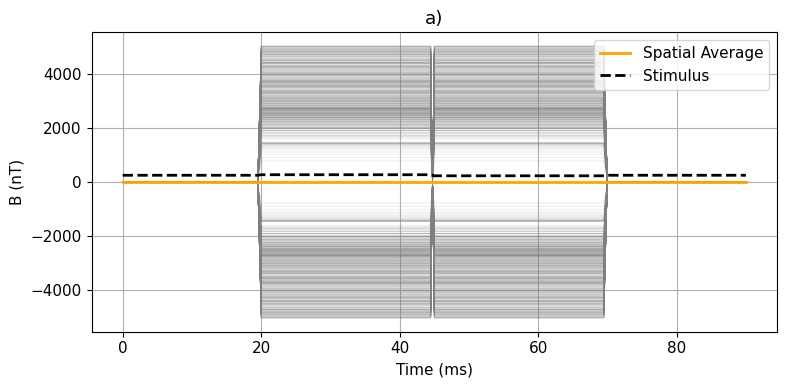

Number of traces: 1681
Spatial average min/max [nT]: -1.565997302088973e-11 1.565997302088973e-11


In [8]:
all_traces = Bcube_nT.reshape(len(t_ms), -1)
spatial_average = np.mean(all_traces, axis=1)

stimulus_plot = np.zeros_like(current_mA, dtype=float)
stimulus_plot[:] = 250
stimulus_plot[(t_ms >= 20) & (t_ms < 45)] = 270
stimulus_plot[(t_ms >= 45) & (t_ms < 70)] = 230
stimulus_plot[(t_ms >= 70)] = 250

plt.figure(figsize=(8, 4))

for i in range(all_traces.shape[1]):
    plt.plot(t_ms, all_traces[:, i], color='gray', alpha=0.10, lw=0.5)

plt.plot(t_ms, spatial_average, color='orange', lw=2, label='Spatial Average')
plt.plot(t_ms, stimulus_plot, 'k--', lw=2, label='Stimulus')

plt.xlabel('Time (ms)')
plt.ylabel('B (nT)')
plt.title('a)')
plt.legend()
plt.tight_layout()
plt.show()

print("Number of traces:", all_traces.shape[1])
print("Spatial average min/max [nT]:", np.min(spatial_average), np.max(spatial_average))

## Plot b

This is a schematic geometry panel:
- the sensing region is the full scan square
- the cylinder projection is shown as a vertical strip
- points A and B lie on the horizontal analysis cut

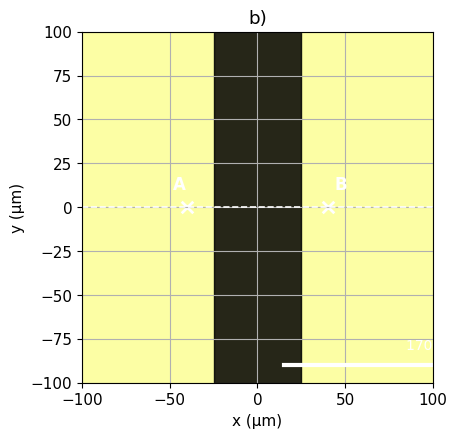

Cylinder radius [um]: 25
Cylinder center height [um]: 35.0
Points A and B shown on the horizontal cut y = 0 um


In [9]:
plt.figure(figsize=(4.8, 4.8))

background = np.ones_like(signal_map_nT)
plt.imshow(
    background,
    extent=[x_um.min(), x_um.max(), y_um.min(), y_um.max()],
    origin='lower',
    cmap='inferno',
    vmin=0,
    vmax=1
)

plt.fill_betweenx(
    [y_um.min(), y_um.max()],
    -wire_radius_um,
    wire_radius_um,
    color='black',
    alpha=0.85,
    label='Cylinder projection'
)

plt.scatter([x_um[ixA], x_um[ixB]], [y_um[iyA], y_um[iyB]], c='white', marker='x', s=70, linewidths=2)
plt.plot([x_um.min(), x_um.max()], [0, 0], 'w--', lw=1.2)

plt.text(x_um[ixA] - 8, y_um[iyA] + 10, 'A', color='white', fontsize=12, weight='bold')
plt.text(x_um[ixB] + 4, y_um[iyB] + 10, 'B', color='white', fontsize=12, weight='bold')

plt.plot([15, 185], [-90, -90], color='white', lw=3)
plt.text(100, -83, '170 µm', color='white', ha='center', va='bottom', fontsize=10)

plt.xlabel('x (µm)')
plt.ylabel('y (µm)')
plt.title('b)')
plt.xlim(x_um.min(), x_um.max())
plt.ylim(y_um.min(), y_um.max())
plt.tight_layout()
plt.show()

print("Cylinder radius [um]:", wire_radius_um)
print("Cylinder center height [um]:", wire_center_z * 1e6)
print("Points A and B shown on the horizontal cut y = 0 um")

## Plot c

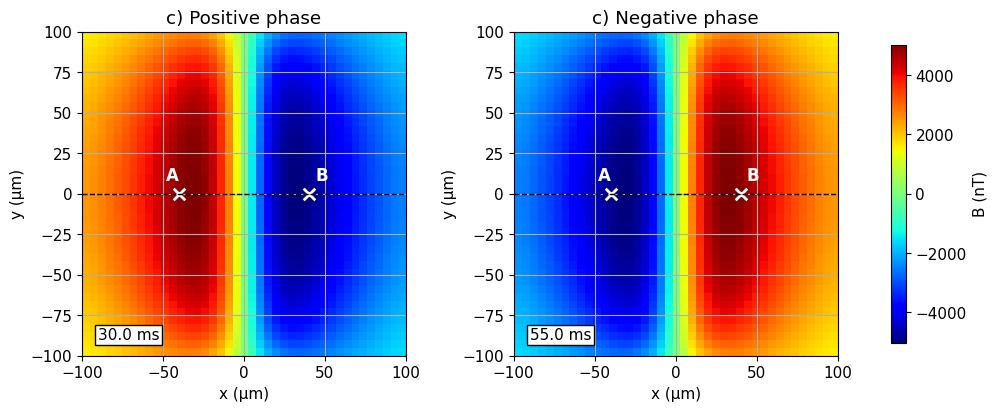

Positive-phase map min/max [nT]: -5028.760442685774 5028.760442686085
Negative-phase map min/max [nT]: -5028.760442686085 5028.760442685774


In [10]:
map_pos = Bcube_nT[it_pos]
map_neg = Bcube_nT[it_neg]

absmax_c = max(np.max(np.abs(map_pos)), np.max(np.abs(map_neg)))
if absmax_c == 0:
    absmax_c = 1.0

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

im1 = axes[0].imshow(
    map_pos,
    extent=[x_um.min(), x_um.max(), y_um.min(), y_um.max()],
    origin='lower',
    aspect='equal',
    cmap='jet',
    vmin=-absmax_c,
    vmax=absmax_c
)
axes[0].scatter([x_um[ixA], x_um[ixB]], [y_um[iyA], y_um[iyB]], c='white', marker='x', s=70, linewidths=2)
axes[0].plot([x_um.min(), x_um.max()], [0, 0], 'k--', lw=1)
axes[0].text(x_um[ixA] - 8, y_um[iyA] + 8, 'A', color='white', fontsize=12, weight='bold')
axes[0].text(x_um[ixB] + 4, y_um[iyB] + 8, 'B', color='white', fontsize=12, weight='bold')
axes[0].text(0.05, 0.05, f'{t_ms[it_pos]:.1f} ms', transform=axes[0].transAxes,
             bbox=dict(facecolor='white', edgecolor='black', pad=2))
axes[0].set_title('c) Positive phase')
axes[0].set_xlabel('x (µm)')
axes[0].set_ylabel('y (µm)')

im2 = axes[1].imshow(
    map_neg,
    extent=[x_um.min(), x_um.max(), y_um.min(), y_um.max()],
    origin='lower',
    aspect='equal',
    cmap='jet',
    vmin=-absmax_c,
    vmax=absmax_c
)
axes[1].scatter([x_um[ixA], x_um[ixB]], [y_um[iyA], y_um[iyB]], c='white', marker='x', s=70, linewidths=2)
axes[1].plot([x_um.min(), x_um.max()], [0, 0], 'k--', lw=1)
axes[1].text(x_um[ixA] - 8, y_um[iyA] + 8, 'A', color='white', fontsize=12, weight='bold')
axes[1].text(x_um[ixB] + 4, y_um[iyB] + 8, 'B', color='white', fontsize=12, weight='bold')
axes[1].text(0.05, 0.05, f'{t_ms[it_neg]:.1f} ms', transform=axes[1].transAxes,
             bbox=dict(facecolor='white', edgecolor='black', pad=2))
axes[1].set_title('c) Negative phase')
axes[1].set_xlabel('x (µm)')
axes[1].set_ylabel('y (µm)')

cbar = fig.colorbar(im2, ax=axes.ravel().tolist(), shrink=0.92)
cbar.set_label('B (nT)')

plt.show()

print("Positive-phase map min/max [nT]:", np.min(map_pos), np.max(map_pos))
print("Negative-phase map min/max [nT]:", np.min(map_neg), np.max(map_neg))

## Plot d

This panel shows the time traces at points A and B, overlaid with the applied stimulus.

Because A and B lie on opposite sides of the cylinder, their signals should have opposite polarity.

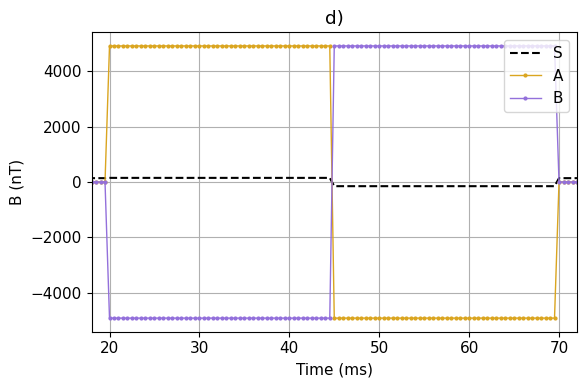

Trace A min/max [nT]: -4919.740786728968 4919.740786728968
Trace B min/max [nT]: -4919.740786729464 4919.740786729464


In [11]:
trace_A = Bcube_nT[:, iyA, ixA]
trace_B = Bcube_nT[:, iyB, ixB]

stimulus_plot_small = np.zeros_like(current_mA, dtype=float)
stimulus_plot_small[:] = 140
stimulus_plot_small[(t_ms >= 20) & (t_ms < 45)] = 150
stimulus_plot_small[(t_ms >= 45) & (t_ms < 70)] = -150
stimulus_plot_small[(t_ms >= 70)] = 140

plt.figure(figsize=(6, 4))

plt.plot(t_ms, stimulus_plot_small, 'k--', lw=1.5, label='S')
plt.plot(t_ms, trace_A, color='goldenrod', marker='o', markersize=2, lw=1, label='A')
plt.plot(t_ms, trace_B, color='mediumpurple', marker='o', markersize=2, lw=1, label='B')

plt.xlabel('Time (ms)')
plt.ylabel('B (nT)')
plt.title('d)')
plt.legend()
plt.xlim(18, 72)
plt.tight_layout()
plt.show()

print("Trace A min/max [nT]:", np.min(trace_A), np.max(trace_A))
print("Trace B min/max [nT]:", np.min(trace_B), np.max(trace_B))

## Plot e

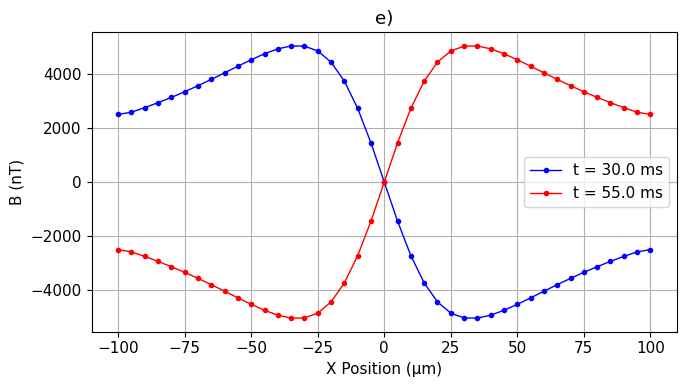

Positive-phase profile min/max [nT]: -5028.760442685774 5028.760442686085
Negative-phase profile min/max [nT]: -5028.760442686085 5028.760442685774
Horizontal cut at y [um]: 0.0


In [12]:
profile_pos = Bcube_nT[it_pos, iy0, :]
profile_neg = Bcube_nT[it_neg, iy0, :]

plt.figure(figsize=(7, 4))

plt.plot(x_um, profile_pos, color='blue', marker='o', markersize=3, lw=1, label=f't = {t_ms[it_pos]:.1f} ms')
plt.plot(x_um, profile_neg, color='red', marker='o', markersize=3, lw=1, label=f't = {t_ms[it_neg]:.1f} ms')

plt.xlabel('X Position (µm)')
plt.ylabel('B (nT)')
plt.title('e)')
plt.legend()
plt.tight_layout()
plt.show()

print("Positive-phase profile min/max [nT]:", np.min(profile_pos), np.max(profile_pos))
print("Negative-phase profile min/max [nT]:", np.min(profile_neg), np.max(profile_neg))
print("Horizontal cut at y [um]:", y_um[iy0])